# Harshly Cleaned Price Prediction with Extras - XGBoost

Let's start by importing necessary packages.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error

Now read in the dataframe and prepare it for use with `XGBoost`.

In [3]:
df = pd.read_parquet("../all_car_details_harshly_cleaned.parquet")

## Preparing Data for XGBoost

Let's first drop useless columns. This time, we will not drop the columns: `comfort_and_convenience`, `entertainment_and_media`, `safety_and_security`, `extras`. Instead we will explode the features into OHE columns, as we have shown in the analysis for it in [important_extra_features.ipynb](../analysis/important_extra_features.ipynb).

In [4]:
columns_to_drop = [
    "url",
    "num_images",
    "general_inspection",
    "emission_class",
    "paint",
]


df.drop(columns=columns_to_drop, errors="ignore", inplace=True)

Now since XGBoost does not need any scaling, imputing of missing values or turning to tensors, let's start by splitting to ensure no data leakage happens and then split the dataset before applying grouping and OHE.

In [5]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# We'll do this after grouping for high cardinality features
high_card_features = ['make', 'car_title'] # Features to apply grouping
# Other categorical features that don't need grouping but need OHE
# Exclude high_card_features as they will be handled, and ensure no numeric features are accidentally included
other_categorical_features = [col for col in X_train.select_dtypes(include=['object', 'category']).columns if col not in high_card_features]
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()

print(f"High cardinality features to group: {high_card_features}")
print(f"Other categorical features for OHE: {other_categorical_features}")
print(f"Numerical features: {numerical_features}")

High cardinality features to group: ['make', 'car_title']
Other categorical features for OHE: ['seller', 'location', 'body_type', 'used_type', 'drivetrain', 'seats', 'doors', 'full_service_history', 'gearbox', 'gears', 'cylinders', 'fuel_type', 'comfort_and_convenience', 'entertainment_and_media', 'safety_and_security', 'extras', 'exterior_colour', 'upholstery_colour', 'upholstery']
Numerical features: ['mileage', 'previous_owner', 'power', 'engine_size', 'empty_weight', 'fuel_consumption', 'co2_emissions', 'age_months']


In [7]:
# --- 5. Grouping High Cardinality Features (Learned from X_train, Applied to X_train & X_test) ---
def get_rare_categories(series, threshold_percentage):
    value_counts_normalized = series.value_counts(normalize=True)
    return value_counts_normalized[value_counts_normalized < threshold_percentage].index

make_threshold_percentage = 0.0001
title_threshold_percentage = 0.00005

# Create copies to avoid SettingWithCopyWarning
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

for feature, threshold in zip(['make', 'car_title'], [make_threshold_percentage, title_threshold_percentage]):
    if feature in X_train_processed.columns:
        print(f"\nProcessing feature: {feature}")
        print(f"Unique values in X_train before grouping: {X_train_processed[feature].nunique()}")
        
        # Learn rare categories from X_train
        rare_categories_train = get_rare_categories(X_train_processed[feature], threshold)
        
        # Apply to X_train
        X_train_processed[feature] = X_train_processed[feature].apply(lambda x: f'Other_{feature}' if x in rare_categories_train else x)
        print(f"Unique values in X_train after grouping: {X_train_processed[feature].nunique()}")
        
        # Apply to X_test (using rare categories learned from X_train)
        if feature in X_test_processed.columns:
            X_test_processed[feature] = X_test_processed[feature].apply(lambda x: f'Other_{feature}' if x in rare_categories_train else x)
            # Handle new categories in X_test not seen in X_train's common categories
            # by mapping them to 'Other_feature' as well
            common_categories_train = X_train_processed[feature].unique()
            X_test_processed[feature] = X_test_processed[feature].apply(lambda x: f'Other_{feature}' if x not in common_categories_train else x)
            print(f"Unique values in X_test after grouping: {X_test_processed[feature].nunique()}")
    else:
        print(f"Feature {feature} not found in X_train.")

# Update the list of categorical features for OHE to include the now-grouped high-cardinality ones
all_categorical_features_for_ohe = high_card_features + other_categorical_features

total_ohe_cols_estimate = 0
print("\n--- Estimating OHE columns ---")
for col in all_categorical_features_for_ohe:
    if col in X_train_processed.columns:
        unique_vals = X_train_processed[col].nunique()
        print(f"Feature '{col}': {unique_vals} unique values (after grouping/filling NaNs)")
        total_ohe_cols_estimate += unique_vals
    else:
        print(f"Feature '{col}' not found in X_train_processed for OHE estimation.")
print(f"Estimated total columns from OHE (if drop=None): {total_ohe_cols_estimate}")
print(f"Numerical features to be passed through: {len(numerical_features)}")
print(f"Grand total estimated features: {total_ohe_cols_estimate + len(numerical_features)}")


Processing feature: make
Unique values in X_train before grouping: 172
Unique values in X_train after grouping: 89
Unique values in X_test after grouping: 89

Processing feature: car_title
Unique values in X_train before grouping: 2018
Unique values in X_train after grouping: 1068
Unique values in X_test after grouping: 1066

--- Estimating OHE columns ---
Feature 'make': 89 unique values (after grouping/filling NaNs)
Feature 'car_title': 1068 unique values (after grouping/filling NaNs)
Feature 'seller': 3 unique values (after grouping/filling NaNs)
Feature 'location': 9 unique values (after grouping/filling NaNs)
Feature 'body_type': 28 unique values (after grouping/filling NaNs)
Feature 'used_type': 6 unique values (after grouping/filling NaNs)
Feature 'drivetrain': 3 unique values (after grouping/filling NaNs)
Feature 'seats': 21 unique values (after grouping/filling NaNs)
Feature 'doors': 8 unique values (after grouping/filling NaNs)
Feature 'full_service_history': 2 unique values

Of course having `326027` columns would not be very efficient, the reason the OHE columns would explode like this is because the previously mentioned 4 extra features are actually composite features with many, many possible combinations. We have to handle these columns separately.

In [8]:
extra_features_for_ohe = ["extras", "comfort_and_convenience",
                          "entertainment_and_media", "safety_and_security"]
all_categorical_features_for_ohe = [
    feature for feature in all_categorical_features_for_ohe if feature not in extra_features_for_ohe]

In [9]:
print("\n--- Processing Composite Extra Features ---")
composite_feature_columns_to_process = ["extras", "comfort_and_convenience", 
                                        "entertainment_and_media", "safety_and_security"]
min_frequency_threshold = 0.05  # Sub-features must be in > 5% of training records
newly_created_binary_sub_features = []

final_sub_features_to_use_map = {
    "extras": [], 
    "comfort_and_convenience": [],
    "entertainment_and_media": [],
    "safety_and_security": []
}

# --- Step 1: Identify frequent sub-features from TRAINING DATA ---
# This step helps you get the lists to then manually curate into `final_sub_features_to_use_map`.
print("Identifying frequent sub-features from X_train_processed (for curation guidance):")
temp_frequent_sub_features_map = {}

for composite_col in composite_feature_columns_to_process:
    # --- Pre-curation Data Cleaning (Example for comfort_and_convenience) ---
    if composite_col == "comfort_and_convenience":
        print(f"  Standardizing 'Panorama roof' to 'Sunroof' for {composite_col} in X_train_processed and X_test_processed.")
        X_train_processed[composite_col] = X_train_processed[composite_col].fillna('').str.replace('Panorama roof', 'Sunroof', regex=False)
        X_test_processed[composite_col] = X_test_processed[composite_col].fillna('').str.replace('Panorama roof', 'Sunroof', regex=False)
    else:
        # Ensure NaNs are handled for other columns too before splitting
        X_train_processed[composite_col] = X_train_processed[composite_col].fillna('')
        X_test_processed[composite_col] = X_test_processed[composite_col].fillna('') # Also fill for test set

    # Explode, strip whitespace, remove empty strings, then count
    sub_feature_series_train = X_train_processed[composite_col].str.split(';').explode().str.strip()
    sub_feature_series_train = sub_feature_series_train[sub_feature_series_train != ''] 
    
    if sub_feature_series_train.empty:
        print(f"  No valid sub-features found for '{composite_col}' in training data after initial processing.")
        final_sub_features_to_use_map[composite_col] = []
        continue
        
    sub_feature_counts_train = sub_feature_series_train.value_counts()
    
    # Identify features meeting the frequency threshold
    frequent_list = sub_feature_counts_train[sub_feature_counts_train > (min_frequency_threshold * len(X_train_processed))].index.tolist()
    print(f"  For '{composite_col}', {len(frequent_list)} sub-features found > {min_frequency_threshold*100:.0f}% threshold (after any standardization).")
    print(f"    First 5: {frequent_list[:5]}")

    # --- Populate final_sub_features_to_use_map with CURATED lists ---
    if composite_col == "extras":
        # Example: final_sub_features_to_use_map["extras"] = [sf for sf in frequent_list if sf != ' unwanted_extra']
        final_sub_features_to_use_map["extras"] = frequent_list # Current: uses all >5%
    elif composite_col == "comfort_and_convenience":
        # `frequent_list` is now based on standardized data (Sunroof instead of Panorama roof)
        features_to_omit_cc = ['Power windows', 'Electrical side mirror', 'Armrest', 'Rain sensor'] # As per your analysis
        curated_cc = [sf for sf in frequent_list if sf not in features_to_omit_cc]
        # The check for 'Panorama roof' in curated_cc should no longer be necessary if standardization worked
        # and 'Panorama roof' itself wasn't frequent enough or was fully replaced.
        final_sub_features_to_use_map["comfort_and_convenience"] = curated_cc
    elif composite_col == "entertainment_and_media":
        curated_em = [sf for sf in frequent_list if sf != 'Radio'] # As per your analysis
        final_sub_features_to_use_map["entertainment_and_media"] = curated_em
    elif composite_col == "safety_and_security":
        features_to_omit_ss = ['ABS', 'Driver-side airbag', 'Passenger-side airbag', 'Power steering', 'Side airbag', 'Electronic stability control', 'Central door lock', 'Immobilizer', 'Isofix'] # Passenger-side airbag typo fixed
        curated_ss = [sf for sf in frequent_list if sf not in features_to_omit_ss]
        final_sub_features_to_use_map["safety_and_security"] = curated_ss
    else:
        final_sub_features_to_use_map[composite_col] = frequent_list # Default

print("\n--- final_sub_features_to_use_map (Curated lists) ---")
for k, v_list in final_sub_features_to_use_map.items():
    print(f"  {k} ({len(v_list)} features): {v_list[:10]}...")

# --- Step 2: Create new binary OHE columns (Optimized to reduce fragmentation) ---
print("\nCreating binary OHE columns from curated sub-feature lists...")

# Prepare dictionaries to hold new columns before concatenating
new_cols_train = {}
new_cols_test = {}

for composite_col, sub_features_to_create_cols_for in final_sub_features_to_use_map.items():
    if not sub_features_to_create_cols_for:
        print(f"  No sub-features to OHE for '{composite_col}'.")
        continue
    
    print(f"  For '{composite_col}', preparing OHE for {len(sub_features_to_create_cols_for)} sub-features.")
    
    # X_train_processed[composite_col] and X_test_processed[composite_col] are already filled with '' for NaNs
    
    for sub_feature in sub_features_to_create_cols_for:
        clean_sub_feature_name = sub_feature.replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '').replace('-', '_').replace('.', '').lower()
        clean_sub_feature_name = ''.join(char for char in clean_sub_feature_name if char.isalnum() or char == '_')
        if not clean_sub_feature_name: clean_sub_feature_name = "unknown"

        new_col_name = f"sf_{composite_col[:3]}_{clean_sub_feature_name}"
        original_new_col_name = new_col_name
        counter = 1
        # Check against all columns being prepared and existing columns
        while new_col_name in X_train_processed.columns or new_col_name in new_cols_train or new_col_name in newly_created_binary_sub_features:
            new_col_name = f"{original_new_col_name}_{counter}"
            counter += 1
        
        # Create Series for new columns
        new_cols_train[new_col_name] = X_train_processed[composite_col].apply(
            lambda x_row_string: 1 if sub_feature in [s.strip() for s in x_row_string.split(';')] else 0
        )
        new_cols_test[new_col_name] = X_test_processed[composite_col].apply(
            lambda x_row_string: 1 if sub_feature in [s.strip() for s in x_row_string.split(';')] else 0
        )
        newly_created_binary_sub_features.append(new_col_name)

# Concatenate all new columns at once
if new_cols_train:
    X_train_processed = pd.concat([X_train_processed, pd.DataFrame(new_cols_train)], axis=1)
    print(f"  Concatenated {len(new_cols_train)} new columns to X_train_processed.")
if new_cols_test:
    X_test_processed = pd.concat([X_test_processed, pd.DataFrame(new_cols_test)], axis=1)
    print(f"  Concatenated {len(new_cols_test)} new columns to X_test_processed.")

print(f"\nTotal new binary sub-features created: {len(newly_created_binary_sub_features)}")

# --- Step 3: Update feature lists and drop original composite columns ---
for feat_name in newly_created_binary_sub_features:
    if feat_name not in numerical_features:
        numerical_features.append(feat_name)
print(f"Added {len(newly_created_binary_sub_features)} new features to 'numerical_features'. Total numerical features: {len(numerical_features)}")

X_train_processed.drop(columns=composite_feature_columns_to_process, inplace=True, errors='ignore')
X_test_processed.drop(columns=composite_feature_columns_to_process, inplace=True, errors='ignore')
print(f"Dropped original composite columns: {composite_feature_columns_to_process}")

print("\n--- Composite Extra Features Processing Complete ---")
print(f"X_train_processed shape: {X_train_processed.shape}, X_test_processed shape: {X_test_processed.shape}")

if newly_created_binary_sub_features:
    print("\nSample of new binary features in X_train_processed:")
    print(X_train_processed[newly_created_binary_sub_features[:min(5, len(newly_created_binary_sub_features))]].head())


--- Processing Composite Extra Features ---
Identifying frequent sub-features from X_train_processed (for curation guidance):
  For 'extras', 26 sub-features found > 5% threshold (after any standardization).
    First 5: ['Alloy wheels', 'Automatically dimming interior mirror', 'Touch screen', 'Voice Control', 'Roof rack']
  Standardizing 'Panorama roof' to 'Sunroof' for comfort_and_convenience in X_train_processed and X_test_processed.
  For 'comfort_and_convenience', 34 sub-features found > 5% threshold (after any standardization).
    First 5: ['Power windows', 'Electrical side mirrors', 'Multi-function steering wheel', 'Park Distance Control', 'Air conditioning']
  For 'entertainment_and_media', 15 sub-features found > 5% threshold (after any standardization).
    First 5: ['Radio', 'On-board computer', 'Bluetooth', 'Hands-free equipment', 'USB']
  For 'safety_and_security', 34 sub-features found > 5% threshold (after any standardization).
    First 5: ['ABS', 'Driver-side airbag'

In [10]:
# --- 6. Preprocessing with ColumnTransformer and Pipeline ---
# XGBoost handles NaNs in numerical features. For categorical, OHE needs a strategy.
# We can impute categorical NaNs with a placeholder like 'Missing' before OHE.

# Create a list of transformers
# For OHE, handle_unknown='ignore' will assign all zeros to categories encountered in test but not in train.
# If NaNs are present in categorical columns, OneHotEncoder will raise an error by default.
# We should fill them or use a specific strategy.
# Let's fill NaNs in categorical columns before OHE for simplicity here.
print("Filling NaNs in categorical features with 'Missing_Cat_Value'...")
for col in all_categorical_features_for_ohe:
    if col in X_train_processed.columns:
        X_train_processed[col] = X_train_processed[col].fillna('Missing_Cat_Value')
    if col in X_test_processed.columns:
        X_test_processed[col] = X_test_processed[col].fillna('Missing_Cat_Value')
        
print("NaNs filled in categorical features.")


# Define the ColumnTransformer
# Numerical features will pass through as XGBoost handles their NaNs and doesn't require scaling.
# If you had numerical features needing imputation/scaling, you'd add a ('num', SimpleImputer/StandardScaler, numerical_features)
preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True, drop=None), all_categorical_features_for_ohe)
    ],
    remainder='passthrough'  # Keep numerical columns not specified in transformers
)
print("Preprocessor created with OneHotEncoder for categorical features and passthrough for numerical features.")

# Fit the preprocessor on X_train_processed and transform both
X_train_final = preprocessor.fit_transform(X_train_processed)
print("Preprocessor fitted and transformed X_train_processed.")
print(f"Type of X_train_final: {type(X_train_final)}") # Should be <class 'scipy.sparse._csr.csr_matrix'> or similar
print(f"Shape of sparse X_train_final: {X_train_final.shape}")

X_test_final = preprocessor.transform(X_test_processed)
print("X_test_processed transformed using the fitted preprocessor.")
print(f"Shape of sparse X_test_final: {X_test_final.shape}")

# Get feature names after OHE for DMatrix or if you want to convert back to DataFrame
# This can be a bit tricky with ColumnTransformer and passthrough.
# Method 1: Get feature names from OneHotEncoder
ohe_feature_names = preprocessor.named_transformers_['ohe'].get_feature_names_out(all_categorical_features_for_ohe)

# Method 2: Construct full list of names
original_cols = X_train_processed.columns.tolist() # Ensure this is defined if not already
passthrough_feature_names = [col for col in original_cols if col not in all_categorical_features_for_ohe]
final_feature_names = list(ohe_feature_names) + passthrough_feature_names
print("Feature names after OHE and passthrough:", final_feature_names)
    
print(f"Number of features after OHE: {len(final_feature_names)}")
# Display some info
# print("\nFirst 5 rows of X_train_final_df:")
# print(X_train_final_df.head())
# print("\nInfo of X_train_final_df:")
# X_train_final_df.info()

Filling NaNs in categorical features with 'Missing_Cat_Value'...
NaNs filled in categorical features.
Preprocessor created with OneHotEncoder for categorical features and passthrough for numerical features.
Preprocessor fitted and transformed X_train_processed.
Type of X_train_final: <class 'scipy.sparse._csr.csr_matrix'>
Shape of sparse X_train_final: (255906, 1442)
X_test_processed transformed using the fitted preprocessor.
Shape of sparse X_test_final: (63977, 1442)
Feature names after OHE and passthrough: ['make_Other_make', 'make_abarth', 'make_aixam', 'make_alfa-romeo', 'make_alpina', 'make_alpine', 'make_aston-martin', 'make_audi', 'make_baic', 'make_byd', 'make_cadillac', 'make_caterham', 'make_cenntro', 'make_chatenet', 'make_chevrolet', 'make_chrysler', 'make_cirelli', 'make_citroen', 'make_corvette', 'make_cupra', 'make_dacia', 'make_daewoo', 'make_daihatsu', 'make_dfsk', 'make_dodge', 'make_dr-automobiles', 'make_ds-automobiles', 'make_emc', 'make_evo', 'make_fiat', 'make_f

In [11]:
# --- 7. Prepare DMatrix for XGBoost ---
# XGBoost DMatrix can directly handle scipy sparse matrices
dtrain = xgb.DMatrix(X_train_final, label=y_train, feature_names=final_feature_names)
dtest = xgb.DMatrix(X_test_final, label=y_test, feature_names=final_feature_names)

print("\nDMatrix created successfully from sparse data.")


DMatrix created successfully from sparse data.


Now we have `1442` features compared to `1346` from before adding the extras. Let's see if they significanlty improve our predictions.

## Train XGBoost

In [12]:
# --- 8. Train a Baseline XGBoost Model ---
print("--- Training Baseline XGBoost Model ---")

# Define baseline parameters
# These are just starting points
params = {
    'objective': 'reg:squarederror',  # For regression tasks, predicts the squared error
    'eval_metric': ['rmse', 'mae'],   # Evaluation metrics: Root Mean Squared Error, Mean Absolute Error
    'eta': 0.1,                       # Learning rate (alias: learning_rate)
    'max_depth': 6,                   # Maximum depth of a tree
    'subsample': 0.8,                 # Subsample ratio of the training instances
    'colsample_bytree': 0.8,          # Subsample ratio of columns when constructing each tree
    'seed': 42                        # For reproducibility
}

num_boost_round = 100  # Number of boosting rounds (trees to build)

# Set up a watchlist to monitor performance on the test set during training
watchlist = [(dtrain, 'train'), (dtest, 'eval')]

print(f"Starting training with {num_boost_round} rounds...")
bst_model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=watchlist,
    early_stopping_rounds=10,  # Stop if performance on eval set doesn't improve for 10 rounds
    verbose_eval=10            # Print evaluation metrics every 10 rounds
)

print("Baseline model training complete.")

--- Training Baseline XGBoost Model ---
Starting training with 100 rounds...
[0]	train-rmse:12559.64790	train-mae:10108.27082	eval-rmse:12578.04687	eval-mae:10128.63548
[10]	train-rmse:6736.32599	train-mae:5007.77016	eval-rmse:6744.02143	eval-mae:5019.52676
[20]	train-rmse:5140.59763	train-mae:3547.33711	eval-rmse:5161.50741	eval-mae:3567.44935
[30]	train-rmse:4598.68808	train-mae:3051.66522	eval-rmse:4633.12734	eval-mae:3077.18714
[40]	train-rmse:4355.05658	train-mae:2843.61088	eval-rmse:4407.28194	eval-mae:2874.09116
[50]	train-rmse:4226.82004	train-mae:2740.96669	eval-rmse:4288.93794	eval-mae:2774.77011
[60]	train-rmse:4125.26801	train-mae:2665.92082	eval-rmse:4197.30715	eval-mae:2702.14128
[70]	train-rmse:4060.04258	train-mae:2615.80455	eval-rmse:4139.64753	eval-mae:2654.46796
[80]	train-rmse:4004.18543	train-mae:2578.07865	eval-rmse:4090.98729	eval-mae:2619.47350
[90]	train-rmse:3958.72234	train-mae:2547.21191	eval-rmse:4055.03753	eval-mae:2591.43278
[99]	train-rmse:3924.77694	tra

In [13]:
# --- 9. Make Predictions and Evaluate Baseline Model ---
print("\n--- Evaluating Baseline Model ---")
y_pred_baseline = bst_model.predict(dtest)

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

print(f"Baseline Model - Test Set Performance:")
print(f"  Mean Absolute Error (MAE): {mae_baseline:.4f}")
print(f"  R-squared (R2): {r2_baseline:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_baseline:.4f}")
print(f"  Mean Absolute Percentage Error (MAPE): {mean_absolute_percentage_error(y_test, y_pred_baseline) * 100:.2f}%")

# You can also access the best score and iteration if early stopping occurred
print(f"Best MAE on eval set during training: {bst_model.best_score:.4f} at iteration {bst_model.best_iteration+1}")


--- Evaluating Baseline Model ---
Baseline Model - Test Set Performance:
  Mean Absolute Error (MAE): 2569.0759
  R-squared (R2): 0.9125
  Root Mean Squared Error (RMSE): 4025.8609
  Mean Absolute Percentage Error (MAPE): 24.07%
Best MAE on eval set during training: 2569.0759 at iteration 100



--- Feature Importance (Baseline Model) ---


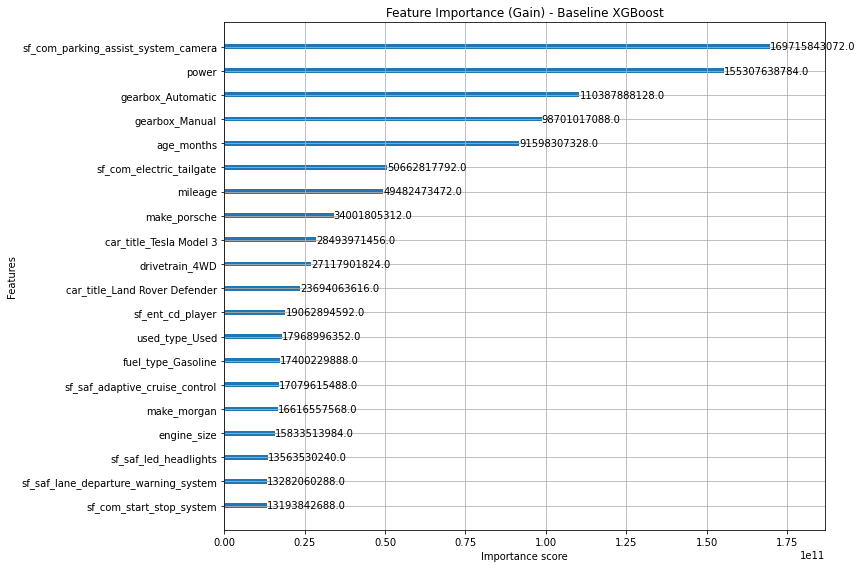

Top 10 features by gain: [('sf_com_parking_assist_system_camera', 169715843072.0), ('power', 155307638784.0), ('gearbox_Automatic', 110387888128.0), ('gearbox_Manual', 98701017088.0), ('age_months', 91598307328.0), ('sf_com_electric_tailgate', 50662817792.0), ('mileage', 49482473472.0), ('make_porsche', 34001805312.0), ('car_title_Tesla Model 3', 28493971456.0), ('drivetrain_4WD', 27117901824.0)]


In [14]:
# --- 10. Feature Importance (Optional but useful) ---
print("\n--- Feature Importance (Baseline Model) ---")
# Plot feature importance
fig, ax = plt.subplots(figsize=(12, 8)) # Adjust height based on num features
xgb.plot_importance(bst_model, ax=ax, max_num_features=20, importance_type='gain') # Show top 20 features by gain
plt.title("Feature Importance (Gain) - Baseline XGBoost")
plt.tight_layout()
plt.show()

# You can also get importance as a dictionary
# importance_types: 'weight', 'gain', 'cover', 'total_gain', 'total_cover'
# 'gain' is often a good default for feature contribution.
feature_importance_gain = bst_model.get_score(importance_type='gain')
print("Top 10 features by gain:", sorted(feature_importance_gain.items(), key=lambda item: item[1], reverse=True)[:10])

It seems like unsurprisingly the make and car_title were the most significant predictors by feature importance.

## Hyperparameter Tuning

In [15]:
# Example using RandomizedSearchCV (conceptual)
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    objective='reg:squarederror',
    seed=42,
    eval_metric='mae',
    early_stopping_rounds=10
)

param_dist = {
    'n_estimators': [100, 200, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5]
}

random_search = RandomizedSearchCV(
    xgb_reg,
    param_distributions=param_dist,
    n_iter=15,  # Number of parameter settings that are sampled
    # Use a score that can be maximized (hence negative MAE)
    scoring='neg_mean_absolute_error',
    cv=2,      # 2-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1  # Use all available cores
)

print("Attempting to start RandomizedSearchCV.fit()...") # Add this line
# Note: RandomizedSearchCV expects dense data or a compatible sparse format.
# X_train_final (if sparse) should work.
random_search.fit(X_train_final, y_train,
                  eval_set=[(X_test_final, y_test)],
                  verbose=True)
print("Best parameters found: ", random_search.best_params_)
print("Best MAE found: ", -random_search.best_score_)
best_xgb_model = random_search.best_estimator_

Attempting to start RandomizedSearchCV.fit()...
Fitting 2 folds for each of 15 candidates, totalling 30 fits


c:\Users\david\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
19 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\david\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\david\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py", line 729, in inner_f
    return func(**kwargs)
  File "c:\Users\david\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\sklearn.py", lin

[0]	validation_0-mae:10063.23593
[1]	validation_0-mae:9216.26046
[2]	validation_0-mae:8460.99866
[3]	validation_0-mae:7792.16934
[4]	validation_0-mae:7200.28872
[5]	validation_0-mae:6690.09130
[6]	validation_0-mae:6225.00380
[7]	validation_0-mae:5815.23269
[8]	validation_0-mae:5450.23287
[9]	validation_0-mae:5130.82576
[10]	validation_0-mae:4850.09252
[11]	validation_0-mae:4601.80962
[12]	validation_0-mae:4380.62527
[13]	validation_0-mae:4194.67222
[14]	validation_0-mae:4024.60056
[15]	validation_0-mae:3873.64352
[16]	validation_0-mae:3744.37587
[17]	validation_0-mae:3627.91601
[18]	validation_0-mae:3524.37095
[19]	validation_0-mae:3432.90606
[20]	validation_0-mae:3345.60805
[21]	validation_0-mae:3270.54769
[22]	validation_0-mae:3202.64897
[23]	validation_0-mae:3147.14737
[24]	validation_0-mae:3097.30811
[25]	validation_0-mae:3051.35728
[26]	validation_0-mae:3009.42248
[27]	validation_0-mae:2972.38057
[28]	validation_0-mae:2941.33148
[29]	validation_0-mae:2912.11756
[30]	validation_0-m

The best MAE found here was not so impressive, so I decide to expand the tree, giving extra max depth such that it can better utilize the greater number of features compared to the base dataset.

In [25]:
# Best parameters found:  {'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
# Best MAE found:  2195.843
best_params = {
    'subsample': 0.7,
    'n_estimators': 1500,
    'min_child_weight': 1,
    'max_depth': 42,
    'learning_rate': 0.01,
    'colsample_bytree': 0.9
}

# Initialize and train the final model
final_model = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='mae',
    early_stopping_rounds=15,
    **best_params  # Unpack the best parameters
)

# Define the evaluation sets. It's good practice to monitor both.
# XGBoost will refer to them as 'validation_0' and 'validation_1' in the results.
evaluation_set_for_final_training = [(X_train_final, y_train), (X_test_final, y_test)]

print("Starting final model training with early stopping and metric tracking...")
final_model.fit(
    X_train_final, y_train,
    eval_set=evaluation_set_for_final_training,
    verbose=True  # Shows MAE at each round or at intervals
)
print("Final model training completed.")

# Retrieve the evaluation results
results = final_model.evals_result()

Starting final model training with early stopping and metric tracking...
[0]	validation_0-mae:10887.71262	validation_1-mae:10910.96489
[1]	validation_0-mae:10784.50992	validation_1-mae:10810.48358
[2]	validation_0-mae:10682.25100	validation_1-mae:10710.78808
[3]	validation_0-mae:10581.16511	validation_1-mae:10612.44567
[4]	validation_0-mae:10481.06192	validation_1-mae:10514.73025
[5]	validation_0-mae:10381.75784	validation_1-mae:10418.13996
[6]	validation_0-mae:10283.46624	validation_1-mae:10322.44301
[7]	validation_0-mae:10186.23106	validation_1-mae:10228.05873
[8]	validation_0-mae:10089.85664	validation_1-mae:10134.25571
[9]	validation_0-mae:9994.37234	validation_1-mae:10041.28143
[10]	validation_0-mae:9900.28690	validation_1-mae:9950.37766
[11]	validation_0-mae:9806.63851	validation_1-mae:9859.57739
[12]	validation_0-mae:9715.11800	validation_1-mae:9771.84595
[13]	validation_0-mae:9624.57616	validation_1-mae:9685.31441
[14]	validation_0-mae:9533.71432	validation_1-mae:9597.39459
[15

## Analyze Results

Let's plot the MAEs to see if it is worth to train for more rounds.

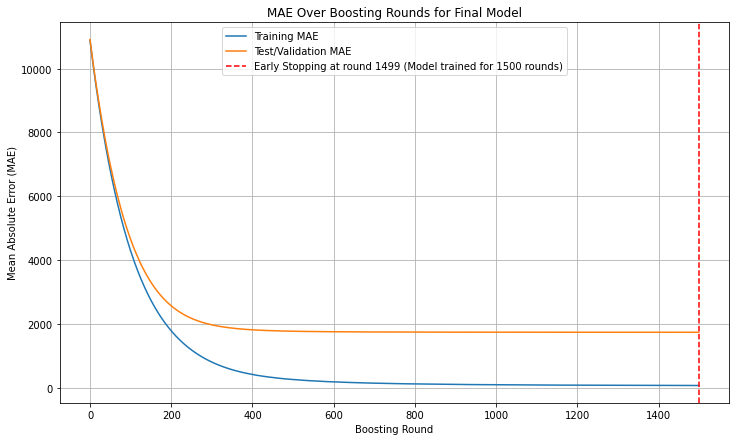

The model was trained for 1500 rounds.
The best MAE achieved on the test set during training was: 1739.91


In [26]:
# Extract MAE history
# 'validation_0' corresponds to the first item in eval_set (X_train_final, y_train)
# 'validation_1' corresponds to the second item in eval_set (X_test_final, y_test)
train_mae_history = results['validation_0']['mae']
test_mae_history = results['validation_1']['mae']

plt.figure(figsize=(12, 7))
plt.plot(train_mae_history, label='Training MAE')
plt.plot(test_mae_history, label='Test/Validation MAE')

# The actual number of boosting rounds run (due to early stopping)
# final_model.best_iteration is the round with the best score (0-indexed)
actual_rounds = final_model.best_iteration + 1
plt.axvline(final_model.best_iteration, color='r', linestyle='--', 
            label=f'Early Stopping at round {final_model.best_iteration} (Model trained for {actual_rounds} rounds)')

plt.title('MAE Over Boosting Rounds for Final Model')
plt.xlabel('Boosting Round')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend()
plt.grid(True)
plt.show()

print(f"The model was trained for {actual_rounds} rounds.")
print(f"The best MAE achieved on the test set during training was: {final_model.best_score:.2f}")

In [27]:
# Predictions
y_train_pred = final_model.predict(X_train_final)
y_test_pred = final_model.predict(X_test_final)

# Training set metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_mape = mean_absolute_percentage_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Test set metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Print results with MSE
print(f"Training Metrics:")
print(f"MAE: {train_mae:.4f}, MSE: {train_mse:.4f}, R²: {train_r2:.4f}, MAPE: {train_mape * 100:.4f}%")
print(f"\nTest Metrics:")
print(f"MAE: {test_mae:.4f}, MSE: {test_mse:.4f}, R²: {test_r2:.4f}, MAPE: {test_mape * 100:.4f}%")

# Residuals
residuals = y_test - y_test_pred

# plt.figure(figsize=(10, 6))
# plt.scatter(y_test_pred, residuals, alpha=0.5, edgecolors="k")
# plt.axhline(y=0, color='red', linestyle='--', lw=2)
# plt.xlabel("Predicted Values")
# plt.ylabel("Residuals (Actual - Predicted)")
# plt.title("Residuals Plot - XGBoost")

Training Metrics:
MAE: 72.5140, MSE: 20601.1878, R²: 0.9999, MAPE: 1.2951%

Test Metrics:
MAE: 1739.9098, MSE: 10039374.8903, R²: 0.9458, MAPE: 16.1302%


This worked well, albeit a bit slowly, let's try some other configurations.

In [19]:
best_params_1000 = {
    'subsample': 0.7,
    'n_estimators': 1000,
    'min_child_weight': 1,
    'max_depth': 25,
    'learning_rate': 0.05,
    'colsample_bytree': 0.9
}

# Initialize and train the final model
final_model_1000 = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='mae',
    early_stopping_rounds=15,
    **best_params_1000  # Unpack the best parameters
)

# Define the evaluation sets. It's good practice to monitor both.
# XGBoost will refer to them as 'validation_0' and 'validation_1' in the results.
evaluation_set_for_final_training_1000 = [(X_train_final, y_train), (X_test_final, y_test)]

print("Starting final model training with early stopping and metric tracking...")
final_model_1000.fit(
    X_train_final, y_train,
    eval_set=evaluation_set_for_final_training_1000,
    verbose=True  # Shows MAE at each round or at intervals
)
print("Final model training completed.")


Starting final model training with early stopping and metric tracking...
[0]	validation_0-mae:10476.41817	validation_1-mae:10514.55659
[1]	validation_0-mae:9980.74957	validation_1-mae:10032.77707
[2]	validation_0-mae:9509.53758	validation_1-mae:9575.51870
[3]	validation_0-mae:9061.82494	validation_1-mae:9142.27632
[4]	validation_0-mae:8636.23000	validation_1-mae:8730.57235
[5]	validation_0-mae:8230.93890	validation_1-mae:8339.44538
[6]	validation_0-mae:7845.52404	validation_1-mae:7968.23773
[7]	validation_0-mae:7478.56067	validation_1-mae:7617.00140
[8]	validation_0-mae:7130.47346	validation_1-mae:7284.73606
[9]	validation_0-mae:6798.45337	validation_1-mae:6969.05062
[10]	validation_0-mae:6484.77406	validation_1-mae:6671.66781
[11]	validation_0-mae:6184.92503	validation_1-mae:6389.62599
[12]	validation_0-mae:5903.09822	validation_1-mae:6128.32818
[13]	validation_0-mae:5635.09692	validation_1-mae:5880.73330
[14]	validation_0-mae:5376.71324	validation_1-mae:5641.10532
[15]	validation_0-m

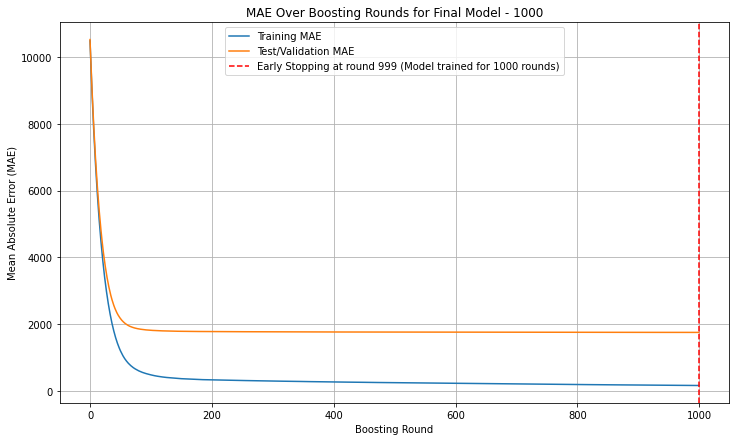

The model was trained for 1000 rounds.
The best MAE achieved on the test set during training was: 1758.70


In [23]:
# Retrieve the evaluation results
results_1000 = final_model_1000.evals_result()

# Extract MAE history
# 'validation_0' corresponds to the first item in eval_set (X_train_final, y_train)
# 'validation_1' corresponds to the second item in eval_set (X_test_final, y_test)
train_mae_history_1000 = results_1000['validation_0']['mae']
test_mae_history_1000 = results_1000['validation_1']['mae']

plt.figure(figsize=(12, 7))
plt.plot(train_mae_history_1000, label='Training MAE')
plt.plot(test_mae_history_1000, label='Test/Validation MAE')

# The actual number of boosting rounds run (due to early stopping)
# final_model.best_iteration is the round with the best score (0-indexed)
actual_rounds_1000 = final_model_1000.best_iteration + 1
plt.axvline(final_model_1000.best_iteration, color='r', linestyle='--', 
            label=f'Early Stopping at round {final_model_1000.best_iteration} (Model trained for {actual_rounds_1000} rounds)')

plt.title('MAE Over Boosting Rounds for Final Model - 1000')
plt.xlabel('Boosting Round')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend()
plt.grid(True)
plt.show()

print(f"The model was trained for {actual_rounds_1000} rounds.")
print(f"The best MAE achieved on the test set during training was: {final_model_1000.best_score:.2f}")

In [28]:
# Predictions
y_train_pred_1000 = final_model_1000.predict(X_train_final)
y_test_pred_1000 = final_model_1000.predict(X_test_final)

# Training set metrics
train_mae_1000 = mean_absolute_error(y_train, y_train_pred_1000)
train_mse_1000 = mean_squared_error(y_train, y_train_pred_1000)  # MSE added
train_r2_1000 = r2_score(y_train, y_train_pred_1000)
train_mape_1000 = mean_absolute_percentage_error(y_train, y_train_pred_1000)

# Test set metrics
test_mae_1000 = mean_absolute_error(y_test, y_test_pred_1000)
test_mse_1000 = mean_squared_error(y_test, y_test_pred_1000)     # MSE added
test_r2_1000 = r2_score(y_test, y_test_pred_1000)
test_mape_1000 = mean_absolute_percentage_error(y_test, y_test_pred_1000)

# Print results with MSE
print(f"Training Metrics:")
print(f"MAE: {train_mae_1000:.4f}, MSE: {train_mse_1000:.4f}, R²: {train_r2_1000:.4f}, MAPE: {train_mape_1000 * 100:.4f}%")
print(f"\nTest Metrics:")
print(f"MAE: {test_mae_1000:.4f}, MSE: {test_mse_1000:.4f}, R²: {test_r2_1000:.4f}, MAPE: {test_mape_1000 * 100:.4f}%")

Training Metrics:
MAE: 170.8632, MSE: 70678.8524, R²: 0.9996, MAPE: 2.5599%

Test Metrics:
MAE: 1758.6967, MSE: 10117854.3940, R²: 0.9454, MAPE: 16.2294%


One more experiment I wanted to do was to not cap the max-depth, give a reasonable number of estimators and higher learning rate to see if that manages to better capture the relations.

In [35]:
max_depth_undefined = {
    'subsample': 0.7,
    'n_estimators': 10000,
    'min_child_weight': 1,
    'max_depth': None,
    'learning_rate': 0.1,
    'colsample_bytree': 0.9
}

# Initialize and train the final model
no_cap_model = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='mae',
    early_stopping_rounds=15,
    **max_depth_undefined  # Unpack the best parameters
)

# Define the evaluation sets. It's good practice to monitor both.
# XGBoost will refer to them as 'validation_0' and 'validation_1' in the results.
evaluation_set_for_final_training = [(X_train_final, y_train), (X_test_final, y_test)]

print("Starting no cap model training with early stopping and metric tracking...")
no_cap_model.fit(
    X_train_final, y_train,
    eval_set=evaluation_set_for_final_training,
    verbose=True  # Shows MAE at each round or at intervals
)
print("Final model training completed.")

# Retrieve the evaluation results
results_no_cap = no_cap_model.evals_result()

Starting no cap model training with early stopping and metric tracking...
[0]	validation_0-mae:10110.41747	validation_1-mae:10131.00460
[1]	validation_0-mae:9269.93224	validation_1-mae:9287.85991
[2]	validation_0-mae:8531.47708	validation_1-mae:8547.47363
[3]	validation_0-mae:7873.29395	validation_1-mae:7886.24542
[4]	validation_0-mae:7284.30127	validation_1-mae:7296.73806
[5]	validation_0-mae:6770.58240	validation_1-mae:6780.59022
[6]	validation_0-mae:6320.55397	validation_1-mae:6330.42326
[7]	validation_0-mae:5915.67528	validation_1-mae:5925.73797
[8]	validation_0-mae:5563.30191	validation_1-mae:5574.50571
[9]	validation_0-mae:5252.47758	validation_1-mae:5264.15317
[10]	validation_0-mae:4976.62318	validation_1-mae:4988.12542
[11]	validation_0-mae:4738.02700	validation_1-mae:4749.84030
[12]	validation_0-mae:4528.38605	validation_1-mae:4540.57729
[13]	validation_0-mae:4346.60420	validation_1-mae:4359.17619
[14]	validation_0-mae:4179.22926	validation_1-mae:4191.92529
[15]	validation_0-m

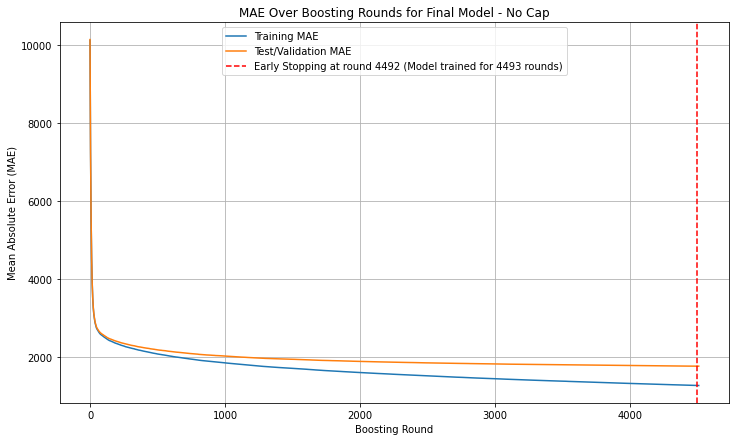

The model was trained for 4493 rounds.
The best MAE achieved on the test set during training was: 1771.66


In [36]:
# Retrieve the evaluation results
results_no_cap = no_cap_model.evals_result()

# Extract MAE history
# 'validation_0' corresponds to the first item in eval_set (X_train_final, y_train)
# 'validation_1' corresponds to the second item in eval_set (X_test_final, y_test)
train_mae_history_no_cap = results_no_cap['validation_0']['mae']
test_mae_history_no_cap = results_no_cap['validation_1']['mae']

plt.figure(figsize=(12, 7))
plt.plot(train_mae_history_no_cap, label='Training MAE')
plt.plot(test_mae_history_no_cap, label='Test/Validation MAE')

# The actual number of boosting rounds run (due to early stopping)
# final_model.best_iteration is the round with the best score (0-indexed)
actual_rounds_no_cap = no_cap_model.best_iteration + 1
plt.axvline(no_cap_model.best_iteration, color='r', linestyle='--', 
            label=f'Early Stopping at round {no_cap_model.best_iteration} (Model trained for {actual_rounds_no_cap} rounds)')

plt.title('MAE Over Boosting Rounds for Final Model - No Cap')
plt.xlabel('Boosting Round')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend()
plt.grid(True)
plt.show()

print(f"The model was trained for {actual_rounds_no_cap} rounds.")
print(f"The best MAE achieved on the test set during training was: {no_cap_model.best_score:.2f}")

In [37]:
# Predictions
y_train_pred_no_cap = no_cap_model.predict(X_train_final)
y_test_pred_no_cap = no_cap_model.predict(X_test_final)

# Training set metrics
train_mae_no_cap = mean_absolute_error(y_train, y_train_pred_no_cap)
train_mse_no_cap = mean_squared_error(y_train, y_train_pred_no_cap)  # MSE added
train_r2_no_cap = r2_score(y_train, y_train_pred_no_cap)
train_mape_no_cap = mean_absolute_percentage_error(y_train, y_train_pred_no_cap)

# Test set metrics
test_mae_no_cap = mean_absolute_error(y_test, y_test_pred_no_cap)
test_mse_no_cap = mean_squared_error(y_test, y_test_pred_no_cap)     # MSE added
test_r2_no_cap = r2_score(y_test, y_test_pred_no_cap)
test_mape_no_cap = mean_absolute_percentage_error(y_test, y_test_pred_no_cap)

# Print results with MSE
print(f"Training Metrics:")
print(f"MAE: {train_mae_no_cap:.4f}, MSE: {train_mse_no_cap:.4f}, R²: {train_r2_no_cap:.4f}, MAPE: {train_mape_no_cap * 100:.4f}%")
print(f"\nTest Metrics:")
print(f"MAE: {test_mae_no_cap:.4f}, MSE: {test_mse_no_cap:.4f}, R²: {test_r2_no_cap:.4f}, MAPE: {test_mape_no_cap * 100:.4f}%")

Training Metrics:
MAE: 1278.1862, MSE: 3410797.4472, R²: 0.9815, MAPE: 13.3336%

Test Metrics:
MAE: 1771.6596, MSE: 9557265.0693, R²: 0.9484, MAPE: 16.7394%


This one had a very nice learning curve, and got our best R2 score, but was not better with its MAE, nor MAPE.

In [38]:
max_depth_05_undefined = {
    'subsample': 0.7,
    'n_estimators': 10000,
    'min_child_weight': 1,
    'max_depth': None,
    'learning_rate': 0.05,
    'colsample_bytree': 0.9
}

# Initialize and train the final model
no_cap_model_05 = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='mae',
    early_stopping_rounds=15,
    **max_depth_05_undefined  # Unpack the best parameters
)

# Define the evaluation sets. It's good practice to monitor both.
# XGBoost will refer to them as 'validation_0' and 'validation_1' in the results.
evaluation_set_for_final_training = [(X_train_final, y_train), (X_test_final, y_test)]

print("Starting no cap model training with early stopping and metric tracking...")
no_cap_model_05.fit(
    X_train_final, y_train,
    eval_set=evaluation_set_for_final_training,
    verbose=True  # Shows MAE at each round or at intervals
)
print("Final model training completed.")

# Retrieve the evaluation results
results_no_cap = no_cap_model_05.evals_result()

Starting no cap model training with early stopping and metric tracking...
[0]	validation_0-mae:10548.00739	validation_1-mae:10568.07061
[1]	validation_0-mae:10102.63759	validation_1-mae:10121.62971
[2]	validation_0-mae:9682.32203	validation_1-mae:9699.94769
[3]	validation_0-mae:9288.44085	validation_1-mae:9304.46157
[4]	validation_0-mae:8914.41024	validation_1-mae:8929.91025
[5]	validation_0-mae:8561.18170	validation_1-mae:8575.34510
[6]	validation_0-mae:8230.26790	validation_1-mae:8242.88460
[7]	validation_0-mae:7916.89039	validation_1-mae:7928.58867
[8]	validation_0-mae:7619.77919	validation_1-mae:7631.37260
[9]	validation_0-mae:7341.29855	validation_1-mae:7352.22373
[10]	validation_0-mae:7078.36958	validation_1-mae:7089.01358
[11]	validation_0-mae:6833.04871	validation_1-mae:6844.34935
[12]	validation_0-mae:6605.44843	validation_1-mae:6617.46599
[13]	validation_0-mae:6391.37826	validation_1-mae:6403.75736
[14]	validation_0-mae:6185.69129	validation_1-mae:6197.85183
[15]	validation_0

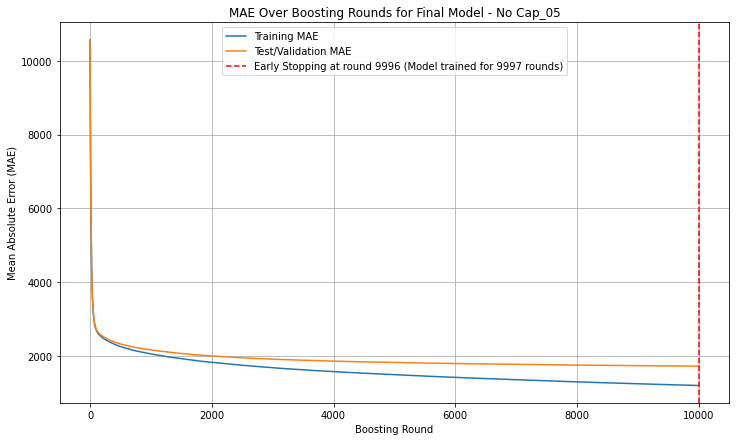

The model was trained for 9997 rounds.
The best MAE achieved on the test set during training was: 1735.70


In [39]:
# Retrieve the evaluation results
results_no_cap_05 = no_cap_model_05.evals_result()

# Extract MAE history
# 'validation_0' corresponds to the first item in eval_set (X_train_final, y_train)
# 'validation_1' corresponds to the second item in eval_set (X_test_final, y_test)
train_mae_history_no_cap_05 = results_no_cap_05['validation_0']['mae']
test_mae_history_no_cap_05 = results_no_cap_05['validation_1']['mae']

plt.figure(figsize=(12, 7))
plt.plot(train_mae_history_no_cap_05, label='Training MAE')
plt.plot(test_mae_history_no_cap_05, label='Test/Validation MAE')

# The actual number of boosting rounds run (due to early stopping)
# final_model.best_iteration is the round with the best score (0-indexed)
actual_rounds_no_cap_05 = no_cap_model_05.best_iteration + 1
plt.axvline(no_cap_model_05.best_iteration, color='r', linestyle='--', 
            label=f'Early Stopping at round {no_cap_model_05.best_iteration} (Model trained for {actual_rounds_no_cap_05} rounds)')

plt.title('MAE Over Boosting Rounds for Final Model - No Cap_05')
plt.xlabel('Boosting Round')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend()
plt.grid(True)
plt.show()

print(f"The model was trained for {actual_rounds_no_cap_05} rounds.")
print(f"The best MAE achieved on the test set during training was: {no_cap_model_05.best_score:.2f}")

In [41]:
# Predictions
y_train_pred_no_cap_05 = no_cap_model_05.predict(X_train_final)
y_test_pred_no_cap_05 = no_cap_model_05.predict(X_test_final)

# Training set metrics
train_mae_no_cap_05 = mean_absolute_error(y_train, y_train_pred_no_cap_05)
train_mse_no_cap_05 = mean_squared_error(y_train, y_train_pred_no_cap_05)  # MSE added
train_r2_no_cap_05 = r2_score(y_train, y_train_pred_no_cap_05)
train_mape_no_cap_05 = mean_absolute_percentage_error(y_train, y_train_pred_no_cap_05)

# Test set metrics
test_mae_no_cap_05 = mean_absolute_error(y_test, y_test_pred_no_cap_05)
test_mse_no_cap_05 = mean_squared_error(y_test, y_test_pred_no_cap_05)     # MSE added
test_r2_no_cap_05 = r2_score(y_test, y_test_pred_no_cap_05)
test_mape_no_cap_05 = mean_absolute_percentage_error(y_test, y_test_pred_no_cap_05)

# Print results with MSE
print(f"Training Metrics:")
print(f"MAE: {train_mae_no_cap_05:.4f}, MSE: {train_mse_no_cap_05:.4f}, R²: {train_r2_no_cap_05:.4f}, MAPE: {train_mape_no_cap_05 * 100:.4f}%")
print(f"\nTest Metrics:")
print(f"MAE: {test_mae_no_cap_05:.4f}, MSE: {test_mse_no_cap_05:.4f}, R²: {test_r2_no_cap_05:.4f}, MAPE: {test_mape_no_cap_05 * 100:.4f}%")

Training Metrics:
MAE: 1212.6710, MSE: 3041479.5255, R²: 0.9835, MAPE: 12.7880%

Test Metrics:
MAE: 1735.6964, MSE: 9336662.8078, R²: 0.9496, MAPE: 16.3438%


This seems to be the best we could get it, let's see some plots for it.

## Plots

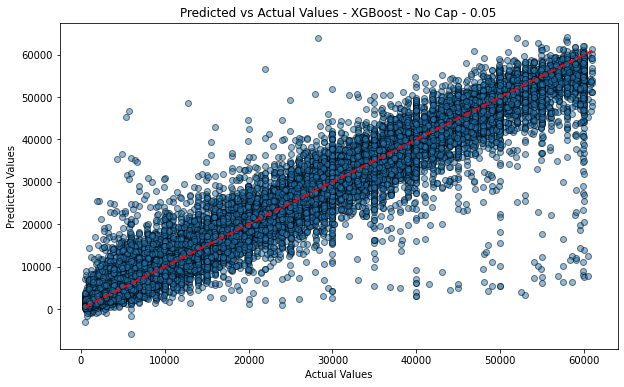

In [43]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred_no_cap_05, alpha=0.5, edgecolors="k")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual Values - XGBoost - No Cap - 0.05")
plt.show()

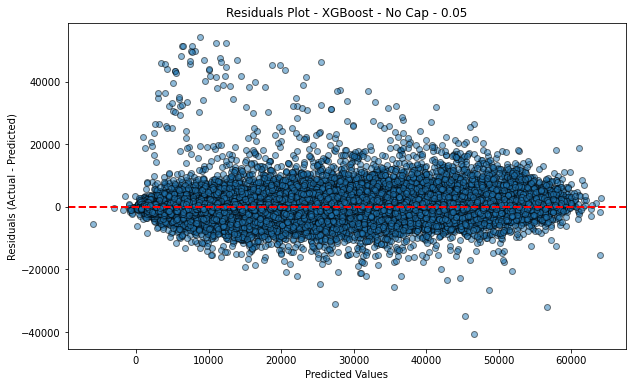

In [44]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred_no_cap_05, residuals, alpha=0.5, edgecolors="k")
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals Plot - XGBoost - No Cap - 0.05")
plt.show()

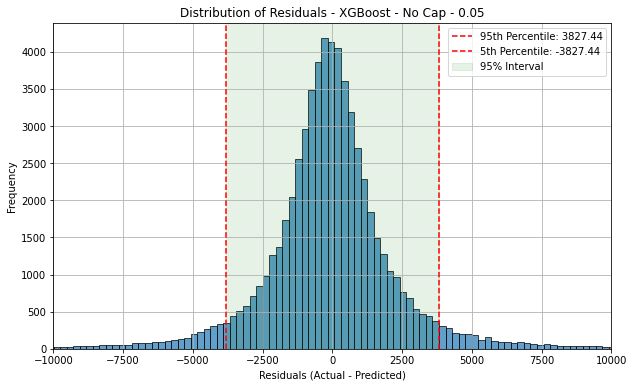

In [46]:
residuals = y_test - y_test_pred_no_cap_05

# Calculate the 95th percentile of the residuals
percentile_95 = np.percentile(residuals, 95)

plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=400, edgecolor='k', alpha=0.7)
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals - XGBoost - No Cap - 0.05')

# Add vertical lines for the 95th percentile
plt.axvline(x=percentile_95, color='r', linestyle='--', label=f'95th Percentile: {percentile_95:.2f}')
plt.axvline(x=-percentile_95, color='r', linestyle='--', label=f'5th Percentile: {-percentile_95:.2f}')

# Optional: Add a shaded region for the 95% interval
plt.axvspan(-percentile_95, percentile_95, color='green', alpha=0.1, label='95% Interval')

plt.grid(True)
plt.xlim(-10000, 10000)
plt.legend()
plt.show()

### Feature Importance

In [48]:
print(type(X_train_final))

<class 'scipy.sparse._csr.csr_matrix'>


In [59]:
feature_names = preprocessor.get_feature_names_out(input_features=X_train_processed.columns)
print(feature_names)

['ohe__make_Other_make' 'ohe__make_abarth' 'ohe__make_aixam' ...
 'remainder__sf_saf_xenon_headlights'
 'remainder__sf_saf_glare_free_high_beam_headlights'
 'remainder__sf_saf_bi_xenon_headlights']


In [61]:
# Assuming you have your model (no_cap_model_05) and feature_names list already
# First, get the Booster object
booster = no_cap_model_05.get_booster()

# Now get the importance scores from the Booster
importance_scores = booster.get_score(importance_type='gain')  # Get importance scores as a dict

# Convert to a sorted list of (feature_index, score) tuples
# Note: XGBoost returns features as 'f0', 'f1', etc., so we need to extract the indices
features = sorted(importance_scores.items(), key=lambda x: x[1], reverse=True)  # Sort by score descending
top_20_indices = [int(feature[0][1:]) for feature in features[:20]]  # Extract indices (e.g., from 'f0' to 0)
top_20_scores = [features[i][1] for i in range(20)]  # Just for reference, if needed

# Now map these indices to your feature_names list
top_20_feature_names = [feature_names[index] for index in top_20_indices]

print(top_20_feature_names)  # Verify these are the correct names for the top 20 features

['ohe__make_porsche', 'remainder__power', 'ohe__make_morgan', 'ohe__car_title_Land Rover Defender', 'ohe__gearbox_Manual', 'remainder__age_months', 'ohe__car_title_Jeep Wrangler', 'ohe__make_mg', 'ohe__make_mercedes-benz', 'remainder__sf_com_electric_tailgate', 'ohe__car_title_Tesla Model 3', 'ohe__make_land-rover', 'ohe__gearbox_Automatic', 'ohe__make_ssangyong', 'ohe__make_alpine', 'ohe__car_title_Suzuki Jimny', 'ohe__make_aston-martin', 'ohe__car_title_Nissan Leaf', 'ohe__car_title_Fiat Tipo', 'ohe__car_title_Porsche 997']


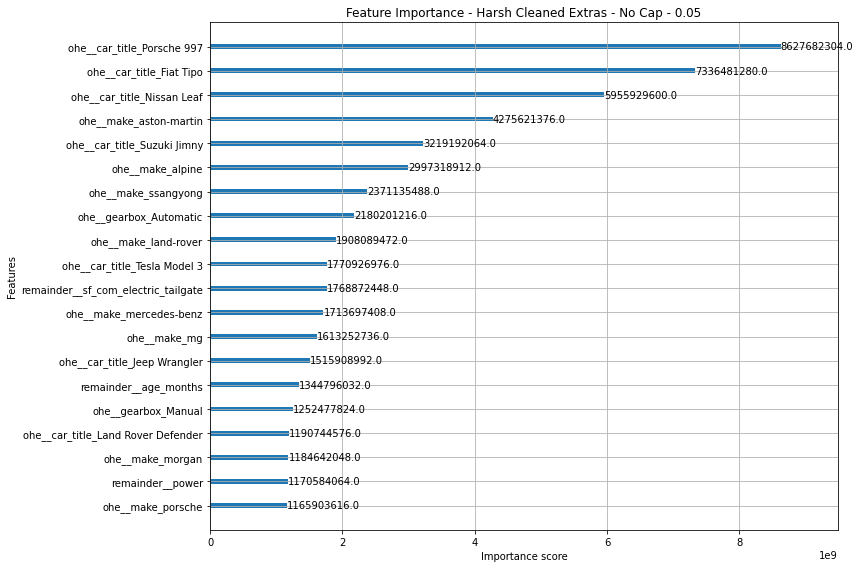

In [65]:
# Create the figure and axis explicitly, just like in the baseline
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the importance on the specific axis
xgb.plot_importance(no_cap_model_05, ax=ax, importance_type='gain', max_num_features=20)

# Set the y-tick labels for the top 20 features
ax.set_yticklabels(top_20_feature_names)  # Make sure top_20_feature_names is defined from your previous steps

# Add title and tighten layout
plt.title("Feature Importance - Harsh Cleaned Extras - No Cap - 0.05")
plt.tight_layout()  # This helps with spacing and readability
plt.show()